## Learning Objectives

* Understand how to prepare data for logistic regression
* Learn to use `statsmodels` with formula notation for categorical variables
* Compare `statsmodels` and `sklearn` implementations
* Evaluate model performance with different classification thresholds
* Interpret confusion matrices and key metrics



##  Import Libraries and Load Data


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# For statsmodels implementation
import statsmodels.formula.api as smf

# For sklearn implementation
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

# Set display options
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')

print("Libraries imported successfully!")

Libraries imported successfully!


In [17]:
# Load the Titanic dataset
titanic = sns.load_dataset('titanic')
titanic = titanic.drop(columns=['pclass']).rename(columns={'class': 'pclass'})
print(f"Dataset shape: {titanic.shape}")
print(f"\nFirst few rows:")
titanic.head()




Dataset shape: (891, 15)

First few rows:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


##  Data Cleaning

We'll focus on:
- **Target variable:** `survived` (0 = died, 1 = survived)
- **Predictors:** `age`, `fare`, `sex`, `pclass`

We'll drop any rows with missing values in these columns.


In [18]:
# Check for missing values in our columns of interest
columns_of_interest = ['survived', 'age', 'fare', 'sex', 'pclass']
print("Missing values in columns of interest:")
print(titanic[columns_of_interest].isnull().sum())



Missing values in columns of interest:
survived      0
age         177
fare          0
sex           0
pclass        0
dtype: int64


In [19]:
titanic.dropna(inplace=True)
print(f"Dataset shape after dropping missing values: {titanic.shape}")
titanic.head()

Dataset shape after dropping missing values: (182, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
10,1,3,female,4.0,1,1,16.7000,S,Third,child,False,G,Southampton,yes,False
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True


In [20]:
# Quick exploratory analysis
print("Target variable distribution:")
print(titanic['survived'].value_counts())




Target variable distribution:
survived
1    123
0     59
Name: count, dtype: int64


In [21]:
# Split into train and test sets
train_df, test_df = train_test_split(titanic, test_size=0.2, random_state=42, stratify=titanic['survived'])


##  Implementation 1: Statsmodels with Formula API

When using `statsmodels.formula.api`, we use the **`C()` notation** to indicate categorical variables:

```python
formula = 'survived ~ age + fare + C(sex) + C(pclass)'
```

**What does `C()` do?**
- Automatically **dummy-codes** categorical variables
- Creates reference categories (first category alphabetically by default)
- For `sex`: female is reference, male gets a coefficient
- For `pclass`: First is reference, Second and Third get coefficients

This is much cleaner than manually creating dummy variables!


In [22]:
# Fit logistic regression using statsmodels
formula = 'survived ~ age + fare + C(sex) + pclass'
statsmodels_logit = smf.logit(formula=formula, data=train_df).fit()

# Display the summary
print(statsmodels_logit.summary())

Optimization terminated successfully.
         Current function value: 0.469735
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:               survived   No. Observations:                  145
Model:                          Logit   Df Residuals:                      140
Method:                           MLE   Df Model:                            4
Date:                Tue, 10 Feb 2026   Pseudo R-squ.:                  0.2543
Time:                        22:56:46   Log-Likelihood:                -68.112
converged:                       True   LL-Null:                       -91.343
Covariance Type:            nonrobust   LLR p-value:                 1.974e-09
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          4.9730      1.227      4.054      0.000       2.569       7.377
C(sex)[T.male]   

### Interpreting the Coefficients

**Key points to discuss (from the printed output):**

1. **Age coefficient (negative, p=0.009):** Older passengers had lower survival odds.
2. **Fare coefficient (near 0, p=0.648):** Fare is not a statistically significant predictor here.
3. **C(sex)[T.male] (negative, p<0.001):** Being male significantly decreased survival odds.
4. **pclass (negative, p=0.077):** Lower passenger class is associated with lower survival odds, but it is not significant at the 0.05 level.

**P-values (P>|z|):**
- Values < 0.05 indicate statistical significance at the 5% level.
- Here, **sex** and **age** are significant; **fare** and **pclass** are not (at 0.05).



In [ ]:
# Get predictions from statsmodels
train_probs_sm = statsmodels_logit.predict(train_df)
test_probs_sm = statsmodels_logit.predict(test_df)

print("Sample of predicted probabilities (statsmodels):")
print(test_probs_sm.head(10))

Sample of predicted probabilities (statsmodels):
3      0.935667
124    0.333831
745    0.212254
809    0.940244
336    0.576382
318    0.935518
66     0.893902
102    0.647346
23     0.596706
690    0.560449
dtype: float64


##  Implementation 2: Scikit-learn Integration

While `statsmodels` is excellent for **statistical inference** (p-values, confidence intervals), `sklearn` is optimized for **prediction and machine learning workflows**.

To use `sklearn.linear_model.LogisticRegression`, we need to:
1. Manually create dummy variables (sklearn doesn't have formula notation)
2. Prepare feature matrix X and target vector y


In [32]:
# Prepare data for sklearn using the same predictors as statsmodels
predictors = ['age', 'fare', 'sex', 'pclass']

X_train = pd.get_dummies(train_df[predictors], columns=['sex' ], drop_first=True)
X_test = pd.get_dummies(test_df[predictors], columns=['sex' ], drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

y_train = train_df['survived']
y_test = test_df['survived']

print("Encoded training data:")
X_train.head()

print(f"\nColumn names: {list(X_train.columns)}")


Encoded training data:

Column names: ['age', 'fare', 'pclass', 'sex_male']


In [33]:
# Feature/target shapes
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"\nFeature names: {list(X_train.columns)}")


X_train shape: (145, 4)
y_train shape: (145,)

Feature names: ['age', 'fare', 'pclass', 'sex_male']


In [34]:
# Fit logistic regression using sklearn
sklearn_logit = LogisticRegression(max_iter=1000, random_state=42)
sklearn_logit.fit(X_train, y_train)

print("Sklearn Logistic Regression model fitted successfully!")
print(f"\nCoefficients:")
for feature, coef in zip(X_train.columns, sklearn_logit.coef_[0]):
    print(f"  {feature:20s}: {coef:8.4f}")
print(f"\nIntercept: {sklearn_logit.intercept_[0]:.4f}")



Sklearn Logistic Regression model fitted successfully!

Coefficients:
  age                 :  -0.0362
  fare                :  -0.0007
  pclass              :  -0.6319
  sex_male            :  -2.0847

Intercept: 4.1754


##  Understanding `.predict()` vs `.predict_proba()`

###  Teaching Point: Two Types of Predictions

Scikit-learn's logistic regression offers two prediction methods:

1. **`.predict_proba()`**: Returns probability estimates
   - Output: Array with shape (n_samples, 2)
   - Column 0: Probability of class 0 (died)
   - Column 1: Probability of class 1 (survived)
   - Values are continuous between 0 and 1

2. **`.predict()`**: Returns class labels
   - Output: Array with shape (n_samples,)
   - Values: 0 or 1 (binary classification)
   - Uses default threshold of 0.5 (if prob ≥ 0.5, predict 1)

**Key difference:** `.predict_proba()` gives you the raw probabilities, while `.predict()` gives you the final classification decision.


In [35]:
# Get probability predictions
test_probs_sklearn = sklearn_logit.predict_proba(X_test)

print("Shape of predict_proba output:", test_probs_sklearn.shape)
print("\nFirst 10 probability predictions:")
print("Index | P(Died) | P(Survived)")
print("-" * 35)
for i in range(10):
    print(f"{i:5d} | {test_probs_sklearn[i, 0]:.4f}  | {test_probs_sklearn[i, 1]:.4f}")

# Extract probabilities of survival (class 1)
test_probs_survival = test_probs_sklearn[:, 1]
print(f"\nProbabilities of survival (class 1): {test_probs_survival[:5]}")



Shape of predict_proba output: (37, 2)

First 10 probability predictions:
Index | P(Died) | P(Survived)
-----------------------------------
    0 | 0.0963  | 0.9037
    1 | 0.6342  | 0.3658
    2 | 0.7551  | 0.2449
    3 | 0.0902  | 0.9098
    4 | 0.4103  | 0.5897
    5 | 0.0904  | 0.9096
    6 | 0.1355  | 0.8645
    7 | 0.3440  | 0.6560
    8 | 0.3965  | 0.6035
    9 | 0.4263  | 0.5737

Probabilities of survival (class 1): [0.90371926 0.36580287 0.24493977 0.90984321 0.58973259]


In [36]:
# Get class predictions (using default 0.5 threshold)
test_pred_default = sklearn_logit.predict(X_test)

print("Shape of predict output:", test_pred_default.shape)
print("\nFirst 10 class predictions:")
print(test_pred_default[:10])

# Compare with probabilities
print("\nComparison of probabilities and predictions:")
print("Index | Probability | Prediction | Interpretation")
print("-" * 60)
for i in range(10):
    prob = test_probs_survival[i]
    pred = test_pred_default[i]
    interpretation = "Survived" if pred == 1 else "Died"
    print(f"{i:5d} | {prob:11.4f} | {pred:10d} | {interpretation}")



Shape of predict output: (37,)

First 10 class predictions:
[1 0 0 1 1 1 1 1 1 1]

Comparison of probabilities and predictions:
Index | Probability | Prediction | Interpretation
------------------------------------------------------------
    0 |      0.9037 |          1 | Survived
    1 |      0.3658 |          0 | Died
    2 |      0.2449 |          0 | Died
    3 |      0.9098 |          1 | Survived
    4 |      0.5897 |          1 | Survived
    5 |      0.9096 |          1 | Survived
    6 |      0.8645 |          1 | Survived
    7 |      0.6560 |          1 | Survived
    8 |      0.6035 |          1 | Survived
    9 |      0.5737 |          1 | Survived


**Observation:** Notice how `.predict()` converts probabilities to 0/1 using the 0.5 threshold:
- Probability ≥ 0.5 → Prediction = 1 (Survived)
- Probability < 0.5 → Prediction = 0 (Died)


##  Evaluation Phase 1: Default Threshold (0.5)

Let's evaluate our model using the standard 0.5 probability threshold.


In [37]:
# Apply 0.5 threshold manually (same as .predict())
threshold_05 = 0.5
test_pred_05 = (test_probs_survival >= threshold_05).astype(int)

# Verify this matches .predict()
print("Manual threshold predictions match .predict()?", np.array_equal(test_pred_05, test_pred_default))



Manual threshold predictions match .predict()? True


In [38]:
# Confusion Matrix
cm_05 = confusion_matrix(y_test, test_pred_05)

print("=" * 50)
print("EVALUATION WITH THRESHOLD = 0.5")
print("=" * 50)
print("\nConfusion Matrix:")
print("                 Predicted")
print("                 Died | Survived")
print(f"Actual Died      {cm_05[0,0]:4d} | {cm_05[0,1]:4d}")
print(f"Actual Survived  {cm_05[1,0]:4d} | {cm_05[1,1]:4d}")

# Calculate metrics
accuracy_05 = accuracy_score(y_test, test_pred_05)
precision_05 = precision_score(y_test, test_pred_05)
recall_05 = recall_score(y_test, test_pred_05)

print(f"\nMetrics:")
print(f"  Accuracy:  {accuracy_05:.4f} ({accuracy_05:.2%})")
print(f"  Precision: {precision_05:.4f} ({precision_05:.2%})")
print(f"  Recall:    {recall_05:.4f} ({recall_05:.2%})")



EVALUATION WITH THRESHOLD = 0.5

Confusion Matrix:
                 Predicted
                 Died | Survived
Actual Died         6 |    6
Actual Survived     3 |   22

Metrics:
  Accuracy:  0.7568 (75.68%)
  Precision: 0.7857 (78.57%)
  Recall:    0.8800 (88.00%)


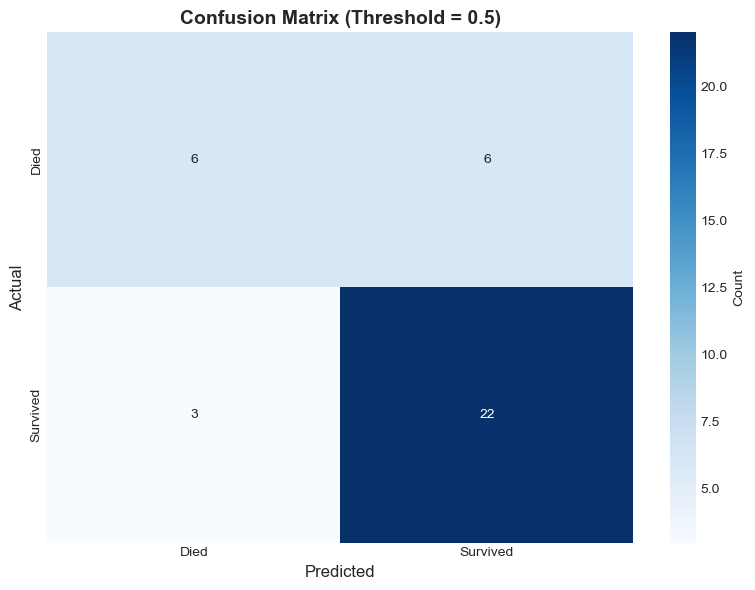


📊 Interpretation:
  True Negatives (TN):  6 - Correctly predicted deaths
  False Positives (FP): 6 - Incorrectly predicted survival (Type I error)
  False Negatives (FN): 3 - Incorrectly predicted death (Type II error)
  True Positives (TP):  22 - Correctly predicted survival


In [39]:
# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_05, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Died', 'Survived'], 
            yticklabels=['Died', 'Survived'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix (Threshold = 0.5)', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

print("\n📊 Interpretation:")
print(f"  True Negatives (TN):  {cm_05[0,0]} - Correctly predicted deaths")
print(f"  False Positives (FP): {cm_05[0,1]} - Incorrectly predicted survival (Type I error)")
print(f"  False Negatives (FN): {cm_05[1,0]} - Incorrectly predicted death (Type II error)")
print(f"  True Positives (TP):  {cm_05[1,1]} - Correctly predicted survival")



##  Evaluation Phase 2: Conservative Threshold (0.7)

###  Teaching Point: Adjusting the Classification Threshold

By **increasing the threshold to 0.7**, we make the model more conservative:
- Only predicts survival if probability ≥ 0.7 (very confident)
- This reduces **False Positives** (fewer incorrect survival predictions)
- But increases **False Negatives** (more missed survival cases)

**When would we use a higher threshold?**
- Medical diagnosis where false alarms are costly
- Fraud detection where investigating false positives is expensive
- Any scenario where precision is more important than recall


In [40]:
# Apply 0.7 threshold
threshold_07 = 0.7
test_pred_07 = (test_probs_survival >= threshold_07).astype(int)

print(f"Number of survival predictions (threshold 0.5): {test_pred_05.sum()}")
print(f"Number of survival predictions (threshold 0.7): {test_pred_07.sum()}")
print(f"\nReduction in survival predictions: {test_pred_05.sum() - test_pred_07.sum()}")



Number of survival predictions (threshold 0.5): 28
Number of survival predictions (threshold 0.7): 18

Reduction in survival predictions: 10


In [41]:
# Confusion Matrix for threshold 0.7
cm_07 = confusion_matrix(y_test, test_pred_07)

print("=" * 50)
print("EVALUATION WITH THRESHOLD = 0.7")
print("=" * 50)
print("\nConfusion Matrix:")
print("                 Predicted")
print("                 Died | Survived")
print(f"Actual Died      {cm_07[0,0]:4d} | {cm_07[0,1]:4d}")
print(f"Actual Survived  {cm_07[1,0]:4d} | {cm_07[1,1]:4d}")

# Calculate metrics
accuracy_07 = accuracy_score(y_test, test_pred_07)
precision_07 = precision_score(y_test, test_pred_07, zero_division=0)
recall_07 = recall_score(y_test, test_pred_07)

print(f"\nMetrics:")
print(f"  Accuracy:  {accuracy_07:.4f} ({accuracy_07:.2%})")
print(f"  Precision: {precision_07:.4f} ({precision_07:.2%})")
print(f"  Recall:    {recall_07:.4f} ({recall_07:.2%})")



EVALUATION WITH THRESHOLD = 0.7

Confusion Matrix:
                 Predicted
                 Died | Survived
Actual Died        12 |    0
Actual Survived     7 |   18

Metrics:
  Accuracy:  0.8108 (81.08%)
  Precision: 1.0000 (100.00%)
  Recall:    0.7200 (72.00%)


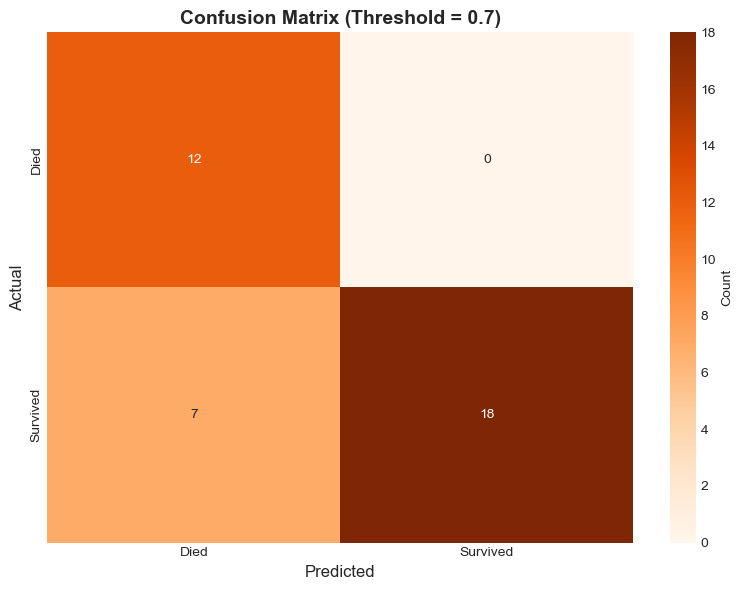


📊 Interpretation:
  True Negatives (TN):  12 - Correctly predicted deaths
  False Positives (FP): 0 - Incorrectly predicted survival
  False Negatives (FN): 7 - Incorrectly predicted death
  True Positives (TP):  18 - Correctly predicted survival


In [42]:
# Visualize confusion matrix for threshold 0.7
plt.figure(figsize=(8, 6))
sns.heatmap(cm_07, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Died', 'Survived'], 
            yticklabels=['Died', 'Survived'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix (Threshold = 0.7)', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

print("\n📊 Interpretation:")
print(f"  True Negatives (TN):  {cm_07[0,0]} - Correctly predicted deaths")
print(f"  False Positives (FP): {cm_07[0,1]} - Incorrectly predicted survival")
print(f"  False Negatives (FN): {cm_07[1,0]} - Incorrectly predicted death")
print(f"  True Positives (TP):  {cm_07[1,1]} - Correctly predicted survival")



##  Comparing Thresholds: Side-by-Side Analysis


In [43]:
# Create comparison table
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'False Positives', 'False Negatives', 'True Positives', 'True Negatives'],
    'Threshold 0.5': [
        f"{accuracy_05:.4f}",
        f"{precision_05:.4f}",
        f"{recall_05:.4f}",
        cm_05[0, 1],
        cm_05[1, 0],
        cm_05[1, 1],
        cm_05[0, 0]
    ],
    'Threshold 0.7': [
        f"{accuracy_07:.4f}",
        f"{precision_07:.4f}",
        f"{recall_07:.4f}",
        cm_07[0, 1],
        cm_07[1, 0],
        cm_07[1, 1],
        cm_07[0, 0]
    ]
})

print("=" * 60)
print("THRESHOLD COMPARISON")
print("=" * 60)
print(comparison_df.to_string(index=False))

print("\n" + "=" * 60)
print("KEY OBSERVATIONS")
print("=" * 60)
print(f"\n1. False Positives:")
print(f"   - Threshold 0.5: {cm_05[0,1]} cases")
print(f"   - Threshold 0.7: {cm_07[0,1]} cases")
print(f"   - Change: {cm_05[0,1] - cm_07[0,1]} (reduction)")

print(f"\n2. False Negatives:")
print(f"   - Threshold 0.5: {cm_05[1,0]} cases")
print(f"   - Threshold 0.7: {cm_07[1,0]} cases")
print(f"   - Change: {cm_07[1,0] - cm_05[1,0]} (increase)")

print(f"\n3. Precision (when we predict survival, how often are we right?):")
print(f"   - Threshold 0.5: {precision_05:.2%}")
print(f"   - Threshold 0.7: {precision_07:.2%}")
print(f"   - Impact: {'INCREASED' if precision_07 > precision_05 else 'DECREASED'}")

print(f"\n4. Recall (of all actual survivors, how many did we find?):")
print(f"   - Threshold 0.5: {recall_05:.2%}")
print(f"   - Threshold 0.7: {recall_07:.2%}")
print(f"   - Impact: {'INCREASED' if recall_07 > recall_05 else 'DECREASED'}")



THRESHOLD COMPARISON
         Metric Threshold 0.5 Threshold 0.7
       Accuracy        0.7568        0.8108
      Precision        0.7857        1.0000
         Recall        0.8800        0.7200
False Positives             6             0
False Negatives             3             7
 True Positives            22            18
 True Negatives             6            12

KEY OBSERVATIONS

1. False Positives:
   - Threshold 0.5: 6 cases
   - Threshold 0.7: 0 cases
   - Change: 6 (reduction)

2. False Negatives:
   - Threshold 0.5: 3 cases
   - Threshold 0.7: 7 cases
   - Change: 4 (increase)

3. Precision (when we predict survival, how often are we right?):
   - Threshold 0.5: 78.57%
   - Threshold 0.7: 100.00%
   - Impact: INCREASED

4. Recall (of all actual survivors, how many did we find?):
   - Threshold 0.5: 88.00%
   - Threshold 0.7: 72.00%
   - Impact: DECREASED


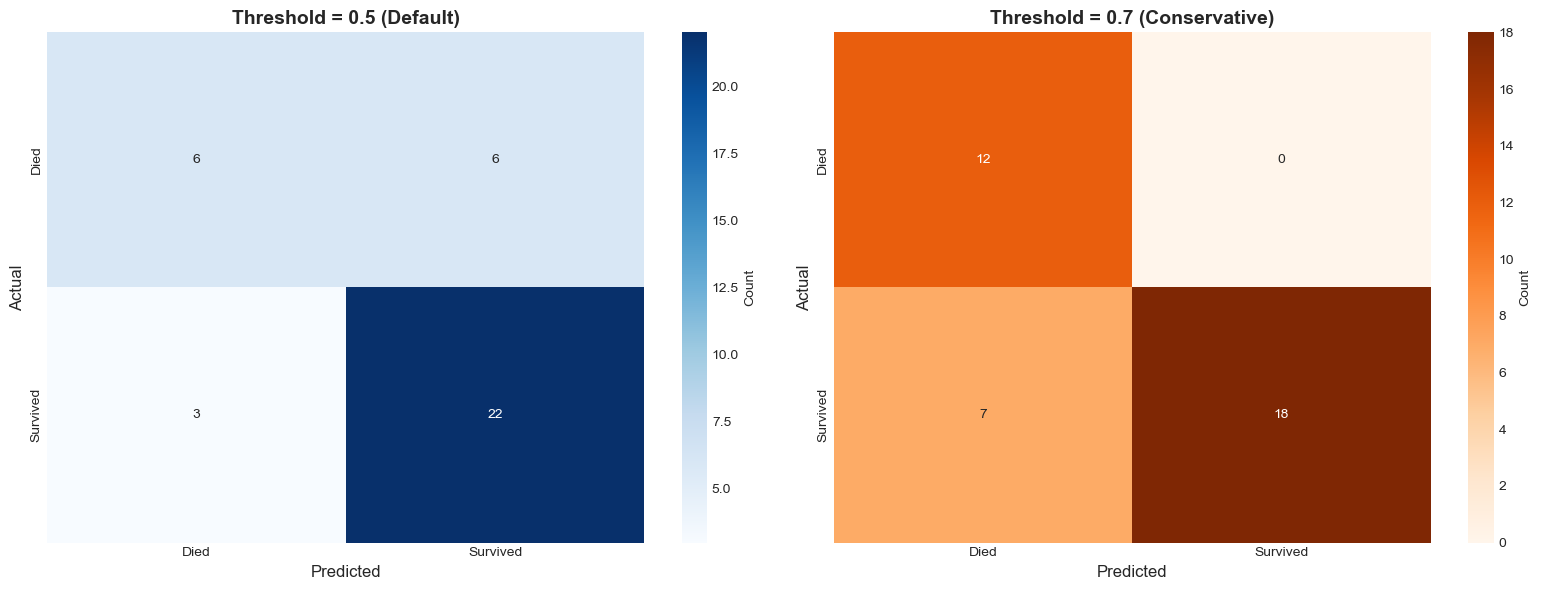

In [44]:
# Visualize side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Threshold 0.5
sns.heatmap(cm_05, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Died', 'Survived'], 
            yticklabels=['Died', 'Survived'],
            cbar_kws={'label': 'Count'})
axes[0].set_title('Threshold = 0.5 (Default)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_xlabel('Predicted', fontsize=12)

# Plot 2: Threshold 0.7
sns.heatmap(cm_07, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Died', 'Survived'], 
            yticklabels=['Died', 'Survived'],
            cbar_kws={'label': 'Count'})
axes[1].set_title('Threshold = 0.7 (Conservative)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Actual', fontsize=12)
axes[1].set_xlabel('Predicted', fontsize=12)

plt.tight_layout()
plt.show()



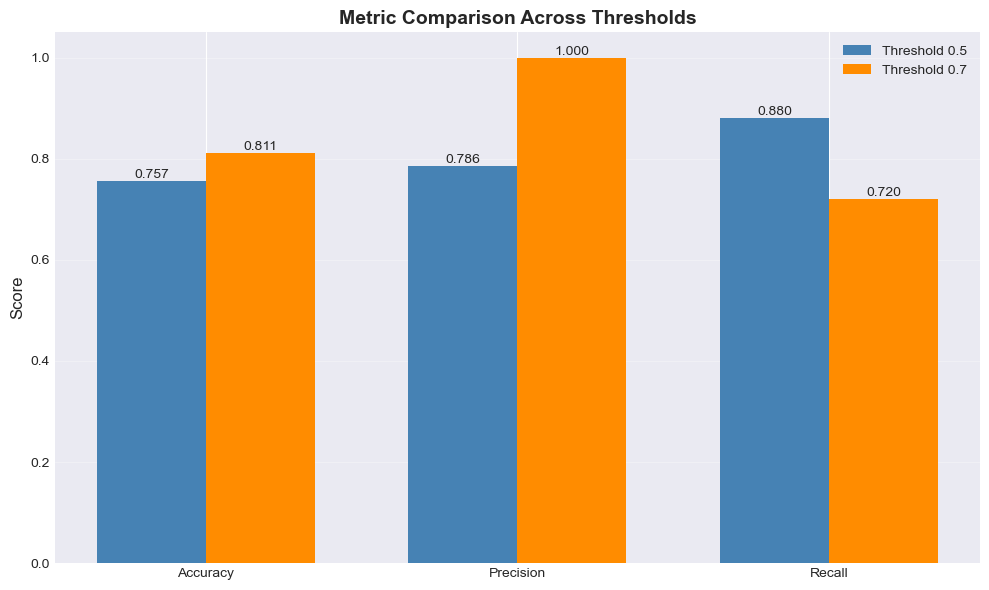

In [45]:
# Bar chart comparison of metrics
metrics = ['Accuracy', 'Precision', 'Recall']
threshold_05_metrics = [accuracy_05, precision_05, recall_05]
threshold_07_metrics = [accuracy_07, precision_07, recall_07]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, threshold_05_metrics, width, label='Threshold 0.5', color='steelblue')
bars2 = ax.bar(x + width/2, threshold_07_metrics, width, label='Threshold 0.7', color='darkorange')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Metric Comparison Across Thresholds', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()



##  Summary and Key Takeaways

###  What We Learned:

1. **Data Preparation:**
   - Cleaned the Titanic dataset by focusing on key variables
   - Handled missing values through simple row deletion

2. **Statsmodels Formula API:**
   - Used `C()` notation for automatic dummy coding of categorical variables
   - Interpreted coefficients and p-values for statistical inference
   - Understood which features significantly predict survival

3. **Sklearn Implementation:**
   - Manually created dummy variables with `pd.get_dummies()`
   - Compared coefficients between statsmodels and sklearn

4. **Prediction Methods:**
   - `.predict_proba()`: Returns continuous probabilities [0, 1]
   - `.predict()`: Returns discrete class labels {0, 1}
   - Default threshold is 0.5

5. **Threshold Impact:**
   - **Higher threshold (0.7)**: More conservative, fewer false positives, higher precision, lower recall
   - **Lower threshold (0.5)**: More sensitive, more false positives, lower precision, higher recall
   - **Trade-off**: Precision vs Recall depends on business needs

###  When to Adjust Thresholds:

- **Increase threshold** when False Positives are costly (e.g., spam detection, medical screening)
- **Decrease threshold** when False Negatives are costly (e.g., disease diagnosis, fraud detection)
- **Keep at 0.5** when both errors are equally important

###  Next Steps:

- Explore ROC curves and AUC for threshold-independent evaluation
- Learn about precision-recall curves
- Try feature engineering to improve model performance
- Experiment with regularization (L1, L2) in logistic regression
